<a href="https://colab.research.google.com/github/devunisathish/NASSCOM-MODULE-1/blob/main/DAY3/DAY3EXERCISE1U6_%E2%80%94_Probability_%26_Statistics_(Part_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

U6 — Probability & Statistics (Part 2): Lab
Probability & Information Theory — axioms · conditional probability · Bayes · distributions · entropy · KL divergence & mutual information

Day 3 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2 (finishing U6)

objectives
By the end of this lab you will be able to:

Estimate probabilities by simulation and apply the basic probability rules

Compute conditional probabilities and test for independence

Apply Bayes' theorem to a real-world (medical-test / spam) scenario

Simulate and plot the Bernoulli, Poisson and Gaussian distributions with SciPy

Compute entropy, KL divergence and mutual information, and interpret them

how to use this lab
Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each # YOUR CODE HERE with working code.

Run cells with Shift + Enter. Run the demos before attempting the exercises.

In [ ]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.0.2


**1. Probability theory & axioms**

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


**LAB EXERCISE 1 — Probability by simulation**
Simulate flipping two coins 100,000 times (0 = tails, 1 = heads):

Estimate P(both heads).
Estimate P(at least one head).
Check the addition idea: does P(0 heads) + P(1 head) + P(2 heads) sum to 1?

In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# 1. P(both heads)  -> heads == 2
p_both_heads = (heads == 2).mean()
print(f'P(both heads): {p_both_heads:.3f}')

# 2. P(at least one head)  -> heads >= 1
p_at_least_one_head = (heads >= 1).mean()
print(f'P(at least one head): {p_at_least_one_head:.3f}')

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0_heads = (heads == 0).mean()
p_1_head = (heads == 1).mean()
p_2_heads = (heads == 2).mean()
sum_probabilities = p_0_heads + p_1_head + p_2_heads
print(f'P(0 heads) + P(1 head) + P(2 heads) = {sum_probabilities:.3f}')


P(both heads): 0.252
P(at least one head): 0.749
P(0 heads) + P(1 head) + P(2 heads) = 1.000


**2. Conditional probability & independence**

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


LAB EXERCISE 2 — Conditional probability
Using fresh dice rolls:

Estimate P(roll is odd | roll < 4).
Estimate P(roll < 4) overall.
Are the events 'roll is odd' and 'roll < 4' independent? Compare P(odd|<4) with P(odd).

In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
rolls_less_than_4 = rolls[rolls < 4] # condition on 'roll < 4'
p_odd_given_less_than_4 = (rolls_less_than_4 % 2 != 0).mean()
print(f'P(odd | roll < 4): {p_odd_given_less_than_4:.3f}')

# 2. P(roll < 4) overall
p_less_than_4 = (rolls < 4).mean()
print(f'P(roll < 4) overall: {p_less_than_4:.3f}')

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = (rolls % 2 != 0).mean()
print(f'P(odd) overall: {p_odd_overall:.3f}')
print(f'Are events independent? {np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=0.02)}')


P(odd | roll < 4): 0.668
P(roll < 4) overall: 0.499
P(odd) overall: 0.503
Are events independent? False


3. Bayes' theorem
P(A | B) = P(B | A) · P(A) / P(B) — update your belief in A after seeing evidence B.

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


LAB EXERCISE 3 — A Bayes scenario (spam filter)
A spam filter: 20% of email is spam. The word "free" appears in 60% of spam but only 5% of real email. An email contains "free" — what's P(spam | "free")?

Write down the prior, likelihood and false-positive rate.
Compute P("free") with the total-probability rule.
Apply Bayes to get P(spam | "free").

In [ ]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_not_spam = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_not_spam)
print(f"P('free') = {p_free:.3f}")

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free') = {p_spam_given_free:.3f}")

P('free') = 0.160
P(spam | 'free') = 0.750


4. Probability distributions

In [11]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


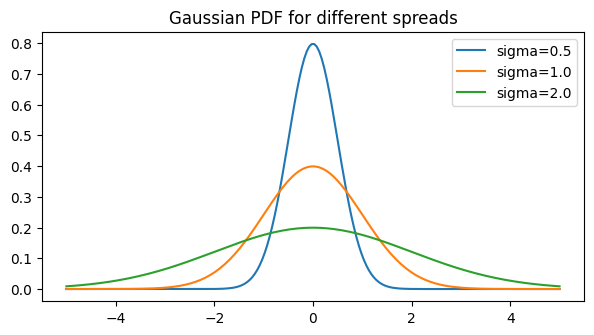

In [12]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

LAB EXERCISE 4 — Simulate & plot distributions
Draw 10,000 samples from a Poisson with mu=2 and print the sample mean.
Plot a histogram of those samples.
Plot the Gaussian PDF for mu=0 with two different sigmas on one chart and observe how the spread changes the curve.

Poisson(2) sample mean ~ 2.006 (true 2)


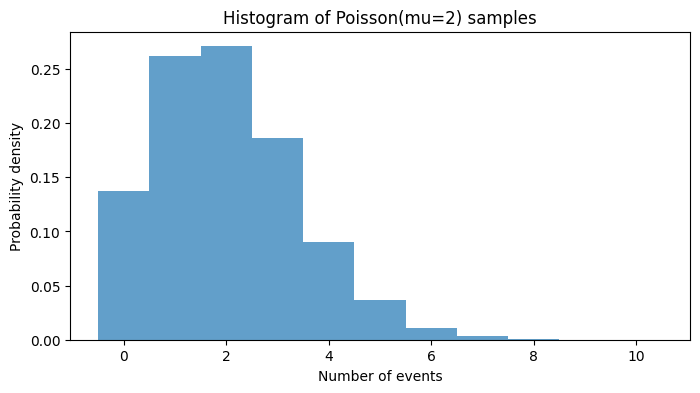

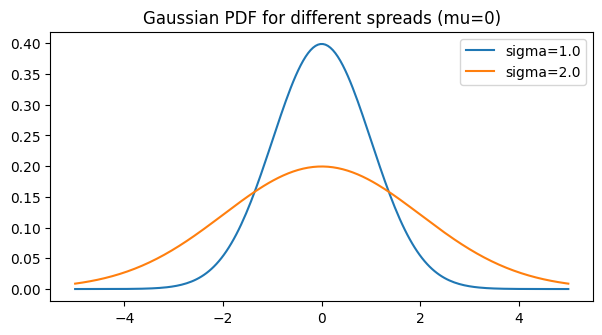

In [13]:
pois_samples = stats.poisson(mu=2).rvs(size=10_000)
print('Poisson(2) sample mean ~', round(pois_samples.mean(), 3), '(true 2)')

plt.figure(figsize=(8, 4))
plt.hist(pois_samples, bins=np.arange(pois_samples.min(), pois_samples.max() + 2) - 0.5, density=True, alpha=0.7)
plt.title('Histogram of Poisson(mu=2) samples')
plt.xlabel('Number of events')
plt.ylabel('Probability density')
plt.show()

x_gaussian = np.linspace(-5, 5, 200)
fig, ax_gaussian = plt.subplots(figsize=(7, 3.5))
for sigma_val in [1.0, 2.0]:
    ax_gaussian.plot(x_gaussian, stats.norm(0, sigma_val).pdf(x_gaussian), label=f'sigma={sigma_val}')
ax_gaussian.set_title('Gaussian PDF for different spreads (mu=0)'); ax_gaussian.legend(); plt.show()

**5. Entropy, KL divergence & mutual information**

In [14]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')


Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [15]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [16]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


LAB EXERCISE 5 — Information theory
Compute the entropy (in bits) of a fair 4-sided die and a fair 6-sided die. Which is more uncertain?
Compute the KL divergence D(P || Q) for P = [0.7, 0.3] and Q = [0.5, 0.5].
From the iris MI scores above, name the most and least informative feature.

In [17]:
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
die_4_sides = [1/4, 1/4, 1/4, 1/4]
die_6_sides = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

entropy_4_sided = entropy(die_4_sides, base=2)
entropy_6_sided = entropy(die_6_sides, base=2)
print(f'Entropy of a fair 4-sided die: {entropy_4_sided:.3f} bits')
print(f'Entropy of a fair 6-sided die: {entropy_6_sided:.3f} bits')
print('The 6-sided die is more uncertain because it has higher entropy.')

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
kl_divergence_pq = entropy(P, Q, base=2)
print(f'KL divergence D(P || Q): {kl_divergence_pq:.3f} bits')

# 3. Most / least informative iris feature (from 5C)
# Most informative: petal length (cm)
# Least informative: sepal width (cm)
print('\nMost informative Iris feature: petal length (cm)')
print('Least informative Iris feature: sepal width (cm)')

Entropy of a fair 4-sided die: 2.000 bits
Entropy of a fair 6-sided die: 2.585 bits
The 6-sided die is more uncertain because it has higher entropy.
KL divergence D(P || Q): 0.119 bits

Most informative Iris feature: petal length (cm)
Least informative Iris feature: sepal width (cm)
